In [1]:
import pandas as pd
import numpy as np
import os
import implicit
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from implicit.evaluation import train_test_split, precision_at_k, ndcg_at_k
import itertools
# ==========================================
# 1. AYARLAR VE VERİ YÜKLEME
# ==========================================
os.environ['OPENBLAS_NUM_THREADS'] = '1'
file_path = '../data/raw/events.csv'

optimized_dtypes = {
    'event_type': 'category',
    'category_code': 'category',
    'brand': 'category',
    'price' : 'float32'
}
columns_to_use = ['event_time', 'event_type', 'product_id', 'category_code', 'brand', 'price', 'user_id']

print("1. Devasa veri okunuyor...")
df = pd.read_csv(file_path, dtype=optimized_dtypes, usecols=columns_to_use)

1. Devasa veri okunuyor...


In [2]:
# ==========================================
# 2. VERİ ÖN İŞLEME (PREPROCESSING)
# ==========================================
print("2. Veri ön işleme yapılıyor...")
df['event_time'] = pd.to_datetime(df['event_time'].str.replace(' UTC', ''), format='%Y-%m-%d %H:%M:%S')
df['brand'] = df['brand'].cat.add_categories('UNKNOWN').fillna('UNKNOWN')
df['category_code'] = df['category_code'].cat.add_categories('UNKNOWN').fillna('UNKNOWN')

user_counts = df['user_id'].value_counts()
active_users = user_counts[user_counts >= 5].index
df_filtered = df[df['user_id'].isin(active_users)].copy()
del df # RAM'i rahatlat

event_weights = {'view': 1.0, 'cart': 3.0, 'purchase': 5.0, 'remove_from_cart': 1.0}
df_filtered['score'] = df_filtered['event_type'].map(event_weights).astype('float32')
df_filtered.drop(columns=['event_type'], inplace=True)

2. Veri ön işleme yapılıyor...


In [3]:
# ==========================================
# 3. KATEGORİ SENKRONİZASYONU VE MATRİS İNŞASI (Eksik Olan Kısım)
# ==========================================
print("3. Kategoriler senkronize ediliyor ve matris kuruluyor...")
df_filtered['user_id'] = df_filtered['user_id'].astype('category').cat.remove_unused_categories()
df_filtered['product_id'] = df_filtered['product_id'].astype('category').cat.remove_unused_categories()

u_categories = df_filtered['user_id'].cat.categories
p_categories = df_filtered['product_id'].cat.categories

row_ind = df_filtered['user_id'].cat.codes.values
col_ind = df_filtered['product_id'].cat.codes.values
data = df_filtered['score'].values

# MATRİS OLUŞTURULUYOR
sparse_user_item = csr_matrix((data, (row_ind, col_ind)), shape=(len(u_categories), len(p_categories)))

3. Kategoriler senkronize ediliyor ve matris kuruluyor...


In [4]:
train_data, test_data = train_test_split(sparse_user_item, train_percentage=0.8, random_state=42)

param_grid = {
    'factors' : [50, 100, 150, 200],
    'regularization' : [0.03, 0.05, 0.1, 0.15 ,0.2],
    'iterations' : [15, 20, 25, 30]
}
keys = param_grid.keys()
combinations = list(itertools.product(*param_grid.values()))

best_precision = 0.0
best_ndcg = 0.0
best_params = {}
best_model = None

for i, combo in enumerate(combinations,1):
    params = dict(zip(keys,combo))

    print(f"[{i}/{len(combinations)}] Denenen Parametreler: {params}")

    model_cv = implicit.als.AlternatingLeastSquares(**params, random_state=42)
    model_cv.fit(train_data, show_progress=True)
    
    
    # Modeli SESSİZCE test et
    p_at_10 = precision_at_k(model_cv, train_data, test_data, K=10, show_progress=True)
    n_at_10 = ndcg_at_k(model_cv, train_data, test_data, K=10, show_progress=True)
    
    print(f"   => Skorlar: Precision: {p_at_10:.4f} | NDCG: {n_at_10:.4f}\n")
    
    if p_at_10 > best_precision:
        best_precision = p_at_10
        best_ndcg = n_at_10
        best_params = params
        best_model = model_cv

# 4. YARIŞMA SONUCU
print("="*50)
print("🏆 OPTİMİZASYON TAMAMLANDI! İŞTE KAZANAN MODEL 🏆")
print("="*50)
print(f"En İyi Parametreler: {best_params}")
print(f"Ulaşılan En Yüksek Precision: {best_precision:.4f}")
print(f"Ulaşılan En Yüksek NDCG:      {best_ndcg:.4f}")
print("="*50)

[1/80] Denenen Parametreler: {'factors': 50, 'regularization': 0.03, 'iterations': 15}


/Users/iberkg/ecommerce_rec_sys/venv/lib/python3.9/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 10 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/1174863 [00:00<?, ?it/s]

  0%|          | 0/1174863 [00:00<?, ?it/s]

...

   => Skorlar: Precision: 0.1368 | NDCG: 0.1151

[80/80] Denenen Parametreler: {'factors': 200, 'regularization': 0.2, 'iterations': 30}


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/1174863 [00:00<?, ?it/s]

  0%|          | 0/1174863 [00:00<?, ?it/s]

   => Skorlar: Precision: 0.1363 | NDCG: 0.1147

🏆 OPTİMİZASYON TAMAMLANDI! İŞTE KAZANAN MODEL 🏆
En İyi Parametreler: {'factors': 200, 'regularization': 0.2, 'iterations': 15}
Ulaşılan En Yüksek Precision: 0.1388
Ulaşılan En Yüksek NDCG:      0.1173


In [5]:
print("\nŞampiyon model TÜM VERİ ile canlı ortam için baştan eğitiliyor...")
final_best_model = implicit.als.AlternatingLeastSquares(**best_params, random_state=42)
final_best_model.fit(sparse_user_item, show_progress=True)

model_data = {
    'model': final_best_model, 
    'user_categories': u_categories,
    'product_categories': p_categories,
    'sparse_user_item': sparse_user_item
}
with open('als_model_best.pkl', 'wb') as f:
    pickle.dump(model_data, f)
print("✅ Şampiyon Model 'als_model_best.pkl' olarak kaydedildi!")


Şampiyon model TÜM VERİ ile canlı ortam için baştan eğitiliyor...


  0%|          | 0/15 [00:00<?, ?it/s]

✅ Şampiyon Model 'als_model_best.pkl' olarak kaydedildi!


In [1]:
# ==========================================
# 5. MODEL BAŞARI KARNESİ (EVALUATION)
# ==========================================
print("\n5. Sınav Başladı! (Train/Test Split & Metrikler)")
train_data, test_data = train_test_split(sparse_user_item, train_percentage=0.8, random_state=42)

eval_model = implicit.als.AlternatingLeastSquares(factors=100, regularization=0.05, iterations=20, random_state=42)
eval_model.fit(train_data)

p_at_10 = precision_at_k(eval_model, train_data, test_data, K=10, show_progress=False)
ndcg_10 = ndcg_at_k(eval_model, train_data, test_data, K=10, show_progress=False)

print("\n" + "="*40)
print("📊 MODEL BAŞARI KARNESİ")
print("="*40)
print(f"Precision@10: {p_at_10:.4f}")
print(f"NDCG@10     : {ndcg_10:.4f}")
print("="*40)


5. Sınav Başladı! (Train/Test Split & Metrikler)


NameError: name 'train_test_split' is not defined


6. Kullanıcı 557746614 İçin Test Başlıyor...
🎯 ÖNERİLER:
1  | Skor: 0.173 | Marka: samsung      | Kategori: electronics.smartphone
2  | Skor: 0.153 | Marka: samsung      | Kategori: electronics.smartphone
3  | Skor: 0.129 | Marka: UNKNOWN      | Kategori: electronics.smartphone
4  | Skor: 0.121 | Marka: samsung      | Kategori: electronics.smartphone
5  | Skor: 0.118 | Marka: samsung      | Kategori: electronics.video.tv
6  | Skor: 0.101 | Marka: samsung      | Kategori: electronics.smartphone
7  | Skor: 0.097 | Marka: samsung      | Kategori: electronics.video.tv
8  | Skor: 0.095 | Marka: samsung      | Kategori: electronics.video.tv
9  | Skor: 0.092 | Marka: lg           | Kategori: electronics.video.tv
10 | Skor: 0.086 | Marka: samsung      | Kategori: electronics.video.tv

7. Görselleştirmeler Hazırlanıyor...


/var/folders/f0/_j9cnf5d13b9092bs4lb86vh0000gn/T/ipykernel_4120/2497119024.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Görüntüleme (1.0)', 'Sepete Ekleme (3.0)', 'Satın Alma (5.0)'],
/var/folders/f0/_j9cnf5d13b9092bs4lb86vh0000gn/T/ipykernel_4120/2497119024.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.values, y=top_brands.index.astype(str), ax=axes[1], palette="crest")
/var/folders/f0/_j9cnf5d13b9092bs4lb86vh0000gn/T/ipykernel_4120/2497119024.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=popular_cat

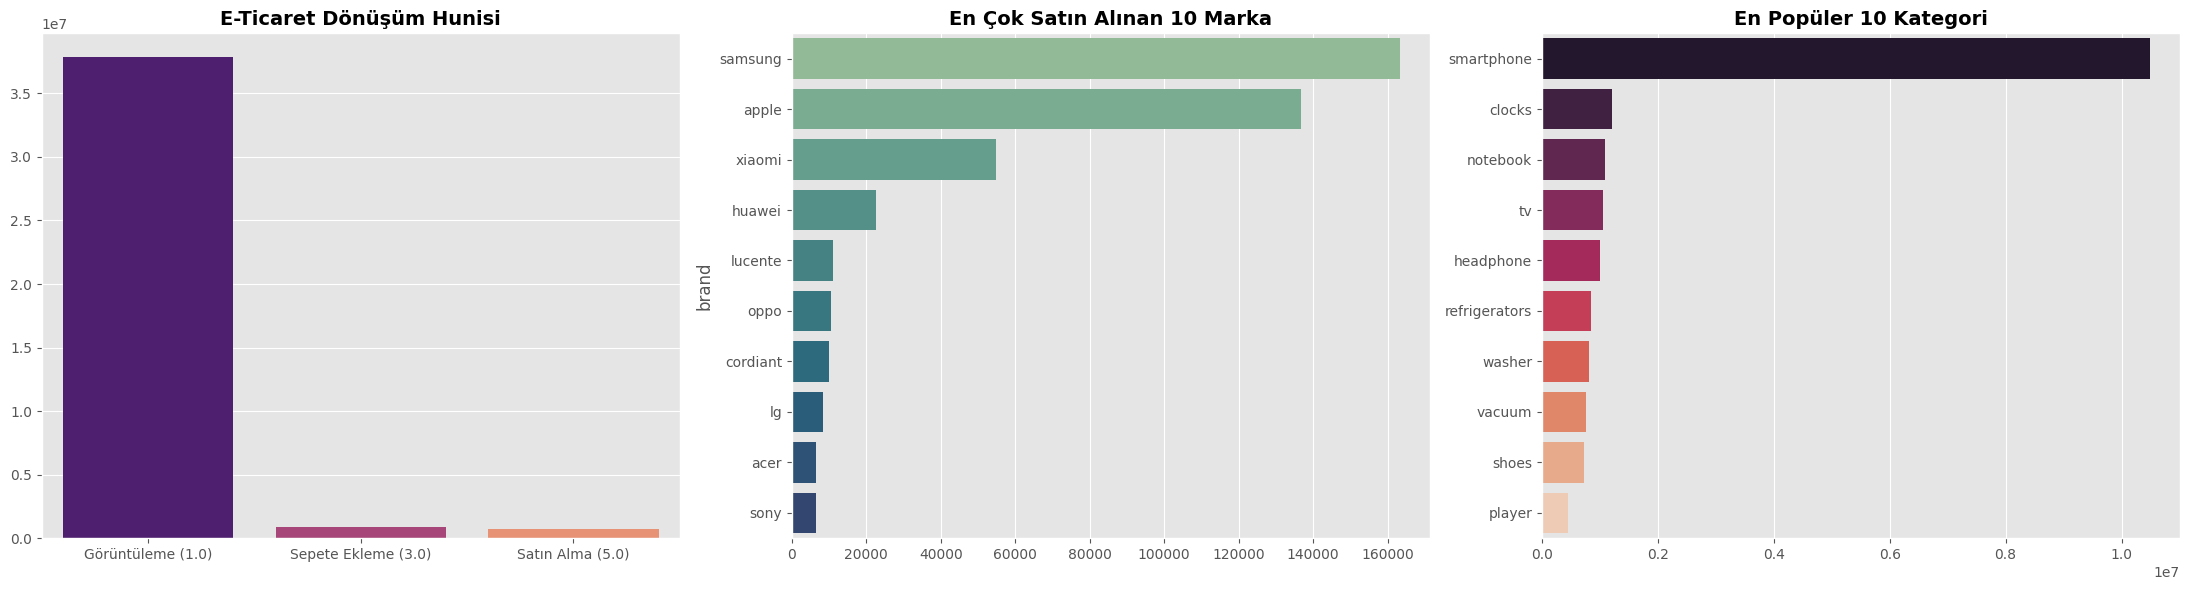

In [7]:
# ==========================================
# 6. TEKİL KULLANICI TESTİ
# ==========================================
target_user = 557746614
print(f"\n6. Kullanıcı {target_user} İçin Test Başlıyor...")

if target_user in u_categories:
    u_idx = u_categories.get_loc(target_user)
    recs, weights = best_model.recommend(u_idx, sparse_user_item[u_idx], N=10)
    
    print("🎯 ÖNERİLER:")
    for i, (p_idx, w) in enumerate(zip(recs, weights)):
        real_id = p_categories[p_idx]
        info = df_filtered[df_filtered['product_id'] == real_id].iloc[0]
        print(f"{i+1:<2} | Skor: {w:.3f} | Marka: {str(info['brand']):<12} | Kategori: {info['category_code']}")
else:
    print("Uyarı: Kullanıcı bulunamadı!")

# ==========================================
# 7. GÖRSELLEŞTİRME (EDA)
# ==========================================
print("\n7. Görselleştirmeler Hazırlanıyor...")
plt.style.use('ggplot')
sns.set_palette("viridis")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

score_counts = df_filtered['score'].value_counts().sort_index()
sns.barplot(x=['Görüntüleme (1.0)', 'Sepete Ekleme (3.0)', 'Satın Alma (5.0)'], 
            y=[score_counts.get(1.0, 0), score_counts.get(3.0, 0), score_counts.get(5.0, 0)], 
            ax=axes[0], palette="magma")
axes[0].set_title("E-Ticaret Dönüşüm Hunisi", fontsize=14, fontweight='bold')

purchases = df_filtered[(df_filtered['score'] == 5.0) & (df_filtered['brand'] != 'UNKNOWN')]
top_brands = purchases['brand'].value_counts().head(10)
sns.barplot(x=top_brands.values, y=top_brands.index.astype(str), ax=axes[1], palette="crest")
axes[1].set_title("En Çok Satın Alınan 10 Marka", fontsize=14, fontweight='bold')

popular_cats = df_filtered[df_filtered['category_code'] != 'UNKNOWN']['category_code'].value_counts().head(10)
short_cats = [str(cat).split('.')[-1] for cat in popular_cats.index]
sns.barplot(x=popular_cats.values, y=short_cats, ax=axes[2], palette="rocket")
axes[2].set_title("En Popüler 10 Kategori", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 